In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [2]:
df=pd.read_csv("country_wise_latest.csv")

In [3]:
df.rename(columns={'New recovered': 'New_Recovered'}, inplace=True)
print(df.columns)

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New_Recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [4]:
df

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New_Recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean
183,Western Sahara,10,1,8,1,0,0,0,10.00,80.00,12.50,10,0,0.00,Africa
184,Yemen,1691,483,833,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean
185,Zambia,4552,140,2815,1597,71,1,465,3.08,61.84,4.97,3326,1226,36.86,Africa


In [5]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New_Recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [6]:
region_df=df[df['WHO Region'] == 'Eastern Mediterranean']
region_df.count()

Country/Region            22
Confirmed                 22
Deaths                    22
Recovered                 22
Active                    22
New cases                 22
New deaths                22
New_Recovered             22
Deaths / 100 Cases        22
Recovered / 100 Cases     22
Deaths / 100 Recovered    22
Confirmed last week       22
1 week change             22
1 week % increase         22
WHO Region                22
dtype: int64

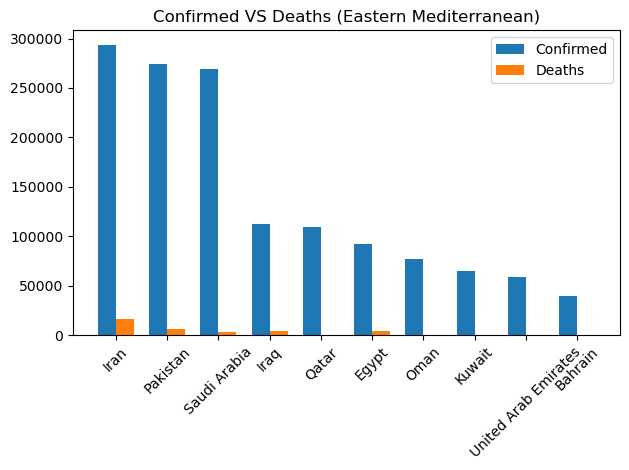

In [8]:
# Death to Confirmed Ratio
region_df = region_df.sort_values(by='Confirmed', ascending=False). head(10)
countries= region_df['Country/Region']
confirmed= region_df['Confirmed']
deaths= region_df['Deaths']

x= np.arange(len(countries))
width=0.35

plt.figure()
plt.bar(x-width/2, confirmed, width, label='Confirmed')
plt.bar(x+width/2, deaths, width, label='Deaths')
plt.xticks(x,countries,rotation=45)
plt.title('Confirmed VS Deaths (Eastern Mediterranean)')
plt.legend()
plt.tight_layout()
plt.show()

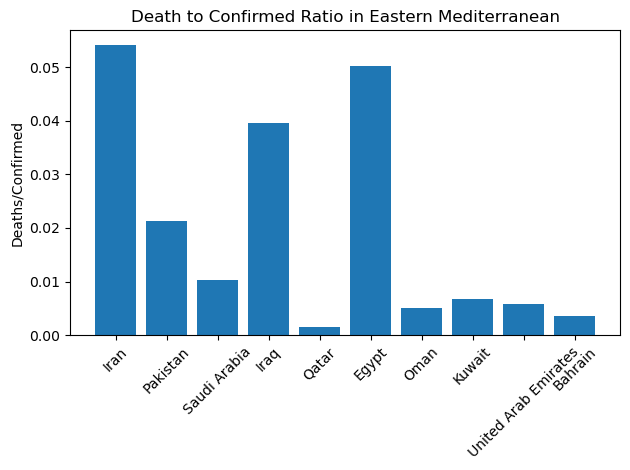

In [19]:
region_df['Death_to_confirmed_Ratio'] = region_df['Deaths']/ region_df['Confirmed']
plt.figure()
plt.bar(region_df['Country/Region'], region_df['Death_to_confirmed_Ratio'])
plt.xticks(rotation=45)
plt.title('Death to Confirmed Ratio in Eastern Mediterranean')
plt.ylabel('Deaths/Confirmed')
plt.tight_layout()
plt.show()

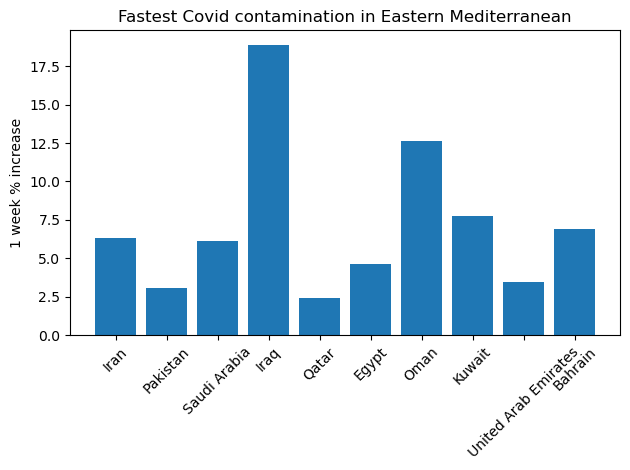

In [12]:
col1= '1 week % increase'
growth= region_df[col1]
plt.figure()
plt.bar(countries, growth)
plt.xticks(rotation= 45)
plt.title('Fastest Covid contamination in Eastern Mediterranean')
plt.ylabel(col1)
plt.tight_layout()
plt.show()

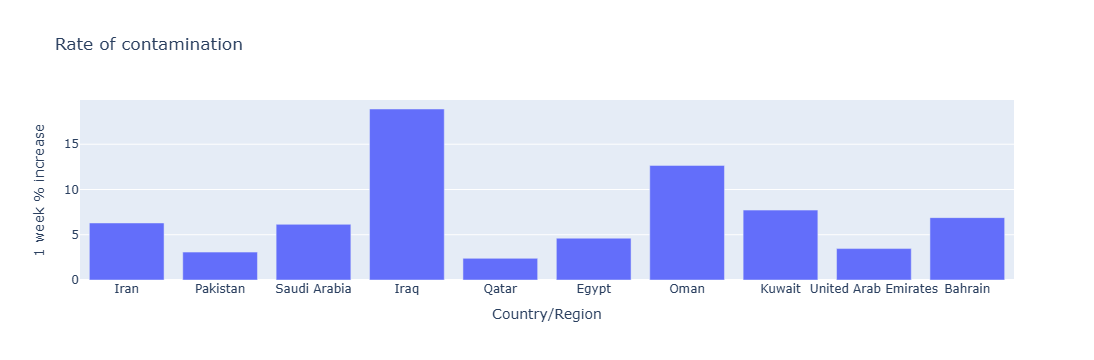

In [22]:
fig= px.bar(
    region_df,
    x='Country/Region',
    y='1 week % increase',
    title='Rate of contamination',
    hover_data= ['1 week % increase']
)
fig.show()

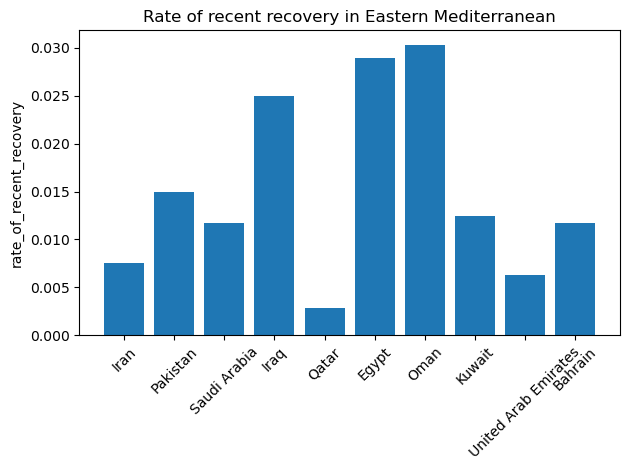

In [18]:
# rate of recovery= recovery/confirmed
# rate of recent recovery= new recovered/recovered
region_df['rate_of_recent_recovery']= region_df['New_Recovered']/region_df['Recovered']
plt.figure()
plt.bar(region_df['Country/Region'], region_df['rate_of_recent_recovery'])
plt.xticks(rotation = 45)
plt.title('Rate of recent recovery in Eastern Mediterranean')
plt.ylabel('rate_of_recent_recovery')
plt.tight_layout()
plt.show()

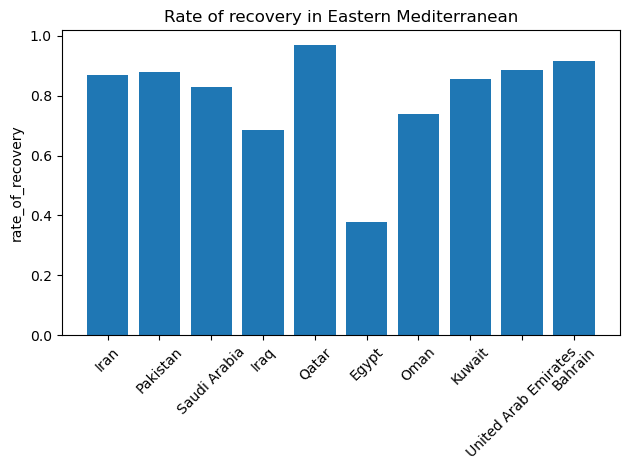

In [20]:
region_df['rate_of_recovery']= region_df['Recovered']/region_df['Confirmed']
plt.figure()
plt.bar(region_df['Country/Region'], region_df['rate_of_recovery'])
plt.xticks(rotation = 45)
plt.title('Rate of recovery in Eastern Mediterranean')
plt.ylabel('rate_of_recovery')
plt.tight_layout()
plt.show()